# Session 8, Notebook 2: Soft versus Hard Boundary Conditions, and the Second Optimizer Stage

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 14:00-14:55, Physics-informed neural networks: foundations
**Slides:** `08_PINNs_Foundations.pdf`
**Notebook role:** in-class walkthrough
**Author:** Simon Scheidegger (HEC, University of Lausanne)

The same equation as Notebook 1 with non-zero boundary values,

$$y''(x) = -1, \quad x \in (0,1), \qquad y(0) = 1, \quad y(1) = 2, \qquad
\text{solution } y(x) = -\tfrac12 x^2 + \tfrac32 x + 1,$$

solved twice: with the boundary conditions as a penalty in the loss (soft), and with a trial
solution that satisfies them by construction (hard). Both runs use the same network, seed,
collocation scheme and number of steps, so the only difference is how the boundary is handled.
Then the two-stage optimizer of the lecture: Adam on resampled points to find the basin, L-BFGS on
a fixed grid to close the residual.

| Section | Content |
|:--|:--|
| 1 | Soft boundary conditions: penalty in the loss |
| 2 | Hard boundary conditions: $\hat y = A(x) + B(x)\,N_\theta(x)$ |
| 3 | Stage two: L-BFGS on a fixed grid, for both |
| 4 | Single against double precision |

In [1]:
SEED = 0

In [2]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED); np.random.seed(SEED)
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                     "legend.fontsize": 9, "font.family": "serif", "mathtext.fontset": "cm",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_TRUE, C_SOFT, C_HARD = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = True   # the stored run writes the figures the slides use
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")


In [3]:
y_exact_fn = lambda x: -0.5 * x**2 + 1.5 * x + 1.0

class Net(nn.Module):
    """1 -> 20 -> 20 -> 1 with tanh activations."""
    def __init__(self, width=20):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(1, width), nn.Tanh(), nn.Linear(width, width), nn.Tanh(), nn.Linear(width, 1))
    def forward(self, x):
        return self.net(x)

def second_derivative(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    return torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]

x_eval = torch.linspace(0, 1, 301).reshape(-1, 1)
def max_error(y_of_x):
    with torch.no_grad():
        return (y_of_x(x_eval) - y_exact_fn(x_eval)).abs().max().item()

## 1. Soft boundary conditions

$$\mathcal{L}_{\text{soft}} = \frac{1}{N}\sum_i \bigl(y''_\theta(x_i) + 1\bigr)^2
  + \bigl(y_\theta(0) - 1\bigr)^2 + \bigl(y_\theta(1) - 2\bigr)^2 .$$

The penalty weight is 1. A larger weight enforces the boundary more tightly and the residual less;
there is no value that makes both exact.

In [4]:
x_bc = torch.tensor([[0.0], [1.0]]); y_bc = torch.tensor([[1.0], [2.0]])

def loss_soft(model, x):
    x = x.clone().requires_grad_(True)
    res = second_derivative(model(x), x) + 1.0
    return torch.mean(res ** 2) + torch.sum((model(x_bc) - y_bc) ** 2)

def train_adam(model, loss_fn, n_steps=5000, n_colloc=50, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(1, n_steps + 1):
        loss = loss_fn(model, torch.rand(n_colloc, 1))
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 1000 == 0 or step == 1:
            print(f"  step {step:5d}  loss {loss.item():.3e}")
    return loss.item()

torch.manual_seed(SEED); model_soft = Net()
t0 = time.time(); adam_loss_soft = train_adam(model_soft, loss_soft)
err_soft_adam = max_error(model_soft)
print(f"soft, after Adam: loss {adam_loss_soft:.2e}, max |error| {err_soft_adam:.2e}  ({time.time() - t0:.0f} s)")

  step     1  loss 7.049e+00


  step  1000  loss 8.890e-03


  step  2000  loss 4.460e-04


  step  3000  loss 2.604e-04


  step  4000  loss 2.666e-04


  step  5000  loss 1.274e-04
soft, after Adam: loss 1.27e-04, max |error| 3.52e-04  (8 s)


## 2. Hard boundary conditions

$$\hat y(x) = \underbrace{1 + x}_{A(x)} + \underbrace{x(1-x)}_{B(x)}\,N_\theta(x)$$

$A$ takes the two boundary values, $B$ vanishes at both ends, so $\hat y(0) = 1$ and $\hat y(1) = 2$
for every network. The loss is the residual alone: nothing to weight, nothing to tune.

In [5]:
def y_hard(model, x):
    return (1.0 + x) + x * (1.0 - x) * model(x)

def loss_hard(model, x):
    x = x.clone().requires_grad_(True)
    res = second_derivative(y_hard(model, x), x) + 1.0
    return torch.mean(res ** 2)

torch.manual_seed(SEED); model_hard = Net()
t0 = time.time(); adam_loss_hard = train_adam(model_hard, loss_hard)
err_hard_adam = max_error(lambda x: y_hard(model_hard, x))
print(f"hard, after Adam: loss {adam_loss_hard:.2e}, max |error| {err_hard_adam:.2e}  ({time.time() - t0:.0f} s)")
print(f"boundary values by construction: {y_hard(model_hard, x_bc).detach().ravel().tolist()}")

  step     1  loss 1.693e+00


  step  1000  loss 8.421e-05


  step  2000  loss 1.990e-06


  step  3000  loss 7.561e-07


  step  4000  loss 3.029e-07


  step  5000  loss 2.065e-07
hard, after Adam: loss 2.06e-07, max |error| 1.04e-05  (8 s)
boundary values by construction: [1.0, 2.0]


## 3. Stage two: L-BFGS on a fixed grid

Adam with resampled points cannot get below a noise floor: every step sees a different loss.
The second stage freezes the collocation points, 200 equally spaced, and runs L-BFGS with a strong
Wolfe line search on that deterministic objective. Resampling inside L-BFGS would break the line
search, which compares loss values along a direction.

In [6]:
x_fixed = torch.linspace(0, 1, 200).reshape(-1, 1)

def polish_lbfgs(model, loss_fn, max_iter=500):
    opt = torch.optim.LBFGS(model.parameters(), max_iter=max_iter, history_size=50,
                            tolerance_grad=1e-14, tolerance_change=1e-16, line_search_fn="strong_wolfe")
    n_eval = [0]
    def closure():
        opt.zero_grad(); loss = loss_fn(model, x_fixed); loss.backward(); n_eval[0] += 1; return loss
    opt.step(closure)
    return loss_fn(model, x_fixed).item(), n_eval[0]

t0 = time.time(); lbfgs_loss_soft, n_soft = polish_lbfgs(model_soft, loss_soft); t_soft = time.time() - t0
err_soft_lbfgs = max_error(model_soft)
t0 = time.time(); lbfgs_loss_hard, n_hard = polish_lbfgs(model_hard, loss_hard); t_hard = time.time() - t0
err_hard_lbfgs = max_error(lambda x: y_hard(model_hard, x))

print(f"{'':6s} {'after Adam (5,000 steps)':>28s} {'after L-BFGS':>22s}")
print(f"{'':6s} {'loss':>12s} {'max error':>14s} {'loss':>10s} {'max error':>11s}  evals  seconds")
print(f"{'soft':6s} {adam_loss_soft:12.2e} {err_soft_adam:14.2e} {lbfgs_loss_soft:10.2e} {err_soft_lbfgs:11.2e} {n_soft:6d} {t_soft:8.1f}")
print(f"{'hard':6s} {adam_loss_hard:12.2e} {err_hard_adam:14.2e} {lbfgs_loss_hard:10.2e} {err_hard_lbfgs:11.2e} {n_hard:6d} {t_hard:8.1f}")

           after Adam (5,000 steps)           after L-BFGS
               loss      max error       loss   max error  evals  seconds
soft       1.27e-04       3.52e-04   2.16e-08    3.20e-06    625      1.5
hard       2.06e-07       1.04e-05   8.13e-10    2.55e-07    540      1.3


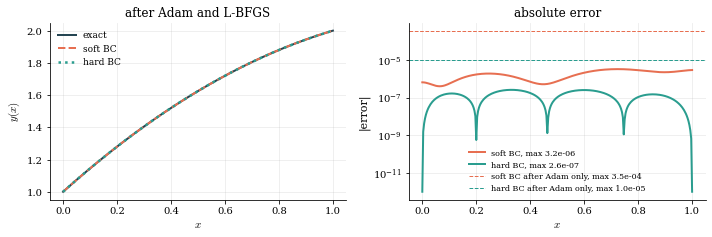

In [7]:
with torch.no_grad():
    x_np = x_eval.numpy().ravel(); y_ex = y_exact_fn(x_eval).numpy().ravel()
    e_soft = (model_soft(x_eval) - y_exact_fn(x_eval)).abs().numpy().ravel()
    e_hard = (y_hard(model_hard, x_eval) - y_exact_fn(x_eval)).abs().numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(x_np, y_ex, color=C_TRUE, lw=2, label="exact")
axes[0].plot(x_np, model_soft(x_eval).detach().numpy().ravel(), "--", color=C_SOFT, lw=2, label="soft BC")
axes[0].plot(x_np, y_hard(model_hard, x_eval).detach().numpy().ravel(), ":", color=C_HARD, lw=2.5, label="hard BC")
axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$y(x)$"); axes[0].legend(frameon=False); axes[0].set_title("after Adam and L-BFGS")
axes[1].semilogy(x_np, np.maximum(e_soft, 1e-12), color=C_SOFT, lw=2, label=f"soft BC, max {err_soft_lbfgs:.1e}")
axes[1].semilogy(x_np, np.maximum(e_hard, 1e-12), color=C_HARD, lw=2, label=f"hard BC, max {err_hard_lbfgs:.1e}")
axes[1].axhline(err_soft_adam, color=C_SOFT, lw=1, ls="--", label=f"soft BC after Adam only, max {err_soft_adam:.1e}")
axes[1].axhline(err_hard_adam, color=C_HARD, lw=1, ls="--", label=f"hard BC after Adam only, max {err_hard_adam:.1e}")
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("|error|"); axes[1].legend(frameon=False, fontsize=8); axes[1].set_title("absolute error")
fig.tight_layout(); savefig(fig, "pinn_softvshard"); plt.show()

## 4. Single against double precision

Everything above ran in `float64`. The second derivative of a `tanh` network and the line search
of L-BFGS both work with small differences of nearly equal numbers, which is where single precision
loses digits. The cell repeats the hard-boundary pipeline in `float32` and reports the same two
numbers, so the comparison is on the same problem, network and seed.

In [8]:
torch.set_default_dtype(torch.float32)
torch.manual_seed(SEED); model_hard32 = Net()
x_eval32 = x_eval.float()
def max_error32(y_of_x):
    with torch.no_grad():
        return (y_of_x(x_eval32).double() - y_exact_fn(x_eval)).abs().max().item()
train_adam(model_hard32, loss_hard)
err32_adam = max_error32(lambda x: y_hard(model_hard32, x))
x_fixed = x_fixed.float()
loss32, n32 = polish_lbfgs(model_hard32, loss_hard)
err32_lbfgs = max_error32(lambda x: y_hard(model_hard32, x))
torch.set_default_dtype(torch.float64); x_fixed = x_fixed.double()

print(f"{'hard BC':10s} {'after Adam':>12s} {'after L-BFGS':>14s} {'L-BFGS loss':>13s}  evals")
print(f"{'float32':10s} {err32_adam:12.2e} {err32_lbfgs:14.2e} {loss32:13.2e} {n32:6d}")
print(f"{'float64':10s} {err_hard_adam:12.2e} {err_hard_lbfgs:14.2e} {lbfgs_loss_hard:13.2e} {n_hard:6d}")

  step     1  loss 2.087e+00


  step  1000  loss 1.501e-05


  step  2000  loss 1.117e-06


  step  3000  loss 7.519e-07


  step  4000  loss 1.136e-06


  step  5000  loss 8.160e-07
hard BC      after Adam   after L-BFGS   L-BFGS loss  evals
float32        6.92e-05       6.79e-07      3.32e-09     55
float64        1.04e-05       2.55e-07      8.13e-10    540


## Summary

* **Same run, twice.** After 5,000 Adam steps the hard-boundary error is 35 times smaller than the
  soft one ($1.0\times10^{-5}$ against $3.5\times10^{-4}$); after L-BFGS it is 12 times smaller
  ($2.6\times10^{-7}$ against $3.2\times10^{-6}$). The soft run's error is largest at the endpoints,
  where the hard run is exact by construction, and there is no penalty weight to tune.
* **The second stage is not optional.** L-BFGS on a fixed set of points improves both runs by two
  orders of magnitude over Adam alone. Adam finds the basin; the deterministic objective and the line
  search close the residual.
* **Precision.** In single precision L-BFGS stops after 55 evaluations at a loss of $3\times10^{-9}$,
  the resolution of the objective in `float32`; in double precision it continues to $8\times10^{-10}$,
  and the error is $2.6\times10^{-7}$ against $6.8\times10^{-7}$. On a CPU double precision costs
  nothing at this size, so every notebook from here on uses it.